<a href="https://colab.research.google.com/github/liaahmujeeb/test_demo/blob/main/Outrix2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve, RocCurveDisplay)
import joblib

xgb_available = True
try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    from sklearn.ensemble import HistGradientBoostingClassifier


In [ ]:
CSV_PATH = "customer_churn_data.csv"
df = pd.read_csv(CSV_PATH)

candidates = ["Churn","churn","CHURN","Exited","exited","Attrition","Attrition_Flag",
              "is_churn","IsChurn","Left","left"]
target_col = None

for c in df.columns:
    if c in candidates:
        target_col = c; break

if target_col is None:
    for c in df.columns:
        if any(h in c.lower() for h in ["churn","exit","attrit","left","leave","cancel"]) and df[c].dropna().nunique()==2:
            target_col = c; break

if target_col is None:
    last = df.columns[-1]
    if df[last].dropna().nunique()==2: target_col = last

if target_col is None:
    raise ValueError("Could not find a binary churn column. Please rename your target to 'Churn' or update target_col manually.")

print("Detected target:", target_col)


Detected target: Churn


In [ ]:
y_raw = df[target_col]
if y_raw.dtype == "O":
    mapping = {'yes':1,'y':1,'true':1,'t':1,'1':1,'churn':1,'exited':1,
               'no':0,'n':0,'false':0,'f':0,'0':0,'retained':0,'stay':0}
    y = y_raw.map(lambda v: mapping.get(str(v).strip().lower(), np.nan))
    if y.isna().mean() > 0.4:
        vc = y_raw.astype(str).str.strip().str.lower().value_counts()
        if len(vc)==2:
            minority = vc.index[-1]
            y = (y_raw.astype(str).str.strip().str.lower()==minority).astype(int)
        else:
            y = pd.to_numeric(y_raw, errors="coerce")2#
else:
    y = pd.to_numeric(y_raw, errors="coerce")

mask = y.notna()
df = df.loc[mask].reset_index(drop=True)
y = y.loc[mask].astype(int).reset_index(drop=True)
X = df.drop(columns=[target_col])

print("Class balance (1=churn):")
print(y.value_counts(normalize=True).rename(lambda k: f"{k}").map(lambda v: f"{v:.2%}"))

Class balance (1=churn):
Churn
0    50.71%
1    49.29%
Name: proportion, dtype: object


In [ ]:
from sklearn.preprocessing import OneHotEncoder

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # >= 1.4
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # <= 1.3

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


In [ ]:
cat_cols = [c for c in X.columns if X[c].dtype == "O" or str(X[c].dtype).startswith("category") or X[c].dtype==bool]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
from sklearn.preprocessing import OneHotEncoder
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])
preprocess.fit(X_train)
Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)
feat_names = []
if num_cols:
    feat_names.extend(num_cols)
if cat_cols:
    ohe_fitted = preprocess.named_transformers_["cat"].named_steps["onehot"]
    feat_names.extend(ohe_fitted.get_feature_names_out(cat_cols).tolist())
if not feat_names:
    feat_names = [f"f{i}" for i in range(Xtr.shape[1])]

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
lr.fit(Xtr, y_train)
if xgb_available:
    xgb = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", n_estimators=200, max_depth=5,
        learning_rate=0.1, subsample=0.9, colsample_bytree=0.9,
        n_jobs=-1, random_state=42
    )
else:
    from sklearn.ensemble import HistGradientBoostingClassifier
    xgb = HistGradientBoostingClassifier(random_state=42)

xgb.fit(Xtr, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

                 model  accuracy  precision    recall        f1   roc_auc
1              XGBoost  0.488095   0.481419  0.491379  0.486348  0.486054
0  Logistic Regression  0.481293   0.472924  0.451724  0.462081  0.474879


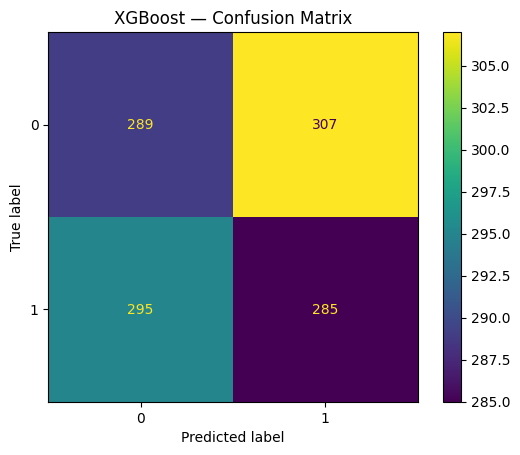

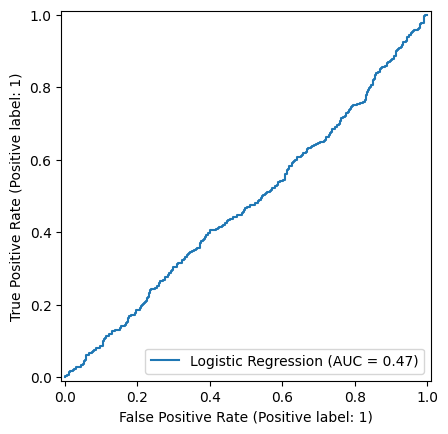

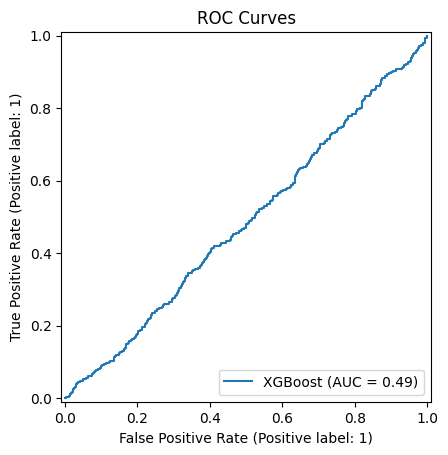

In [ ]:
def evaluate(name, model, X, y):
    proba = model.predict_proba(X)[:,1] if hasattr(model, "predict_proba") else model.predict(X)
    pred  = (proba >= 0.5).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
    }
    return metrics, pred, proba
m_lr, ypred_lr, yprob_lr = evaluate("Logistic Regression", lr, Xte, y_test)
m_xg, ypred_xg, yprob_xg = evaluate("XGBoost" if xgb_available else "HGB", xgb, Xte, y_test)
print(pd.DataFrame([m_lr, m_xg]).sort_values("roc_auc", ascending=False))
best = m_xg if m_xg["roc_auc"] >= m_lr["roc_auc"] else m_lr
best_pred = ypred_xg if best is m_xg else ypred_lr
best_name = best["model"]
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f"{best_name} — Confusion Matrix")
plt.show()
RocCurveDisplay.from_predictions(y_test, yprob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, yprob_xg, name=("XGBoost" if xgb_available else "HGB"))
plt.title("ROC Curves")
plt.show()

In [ ]:
lr_imp = (pd.DataFrame({"feature": feat_names, "coef": lr.coef_.ravel()})
            .assign(importance=lambda d: d["coef"].abs())
            .sort_values("importance", ascending=False))
print("Top LR features:\n", lr_imp.head(15))
if xgb_available and hasattr(xgb, "feature_importances_"):
    xgb_imp = pd.DataFrame({"feature": feat_names, "importance": xgb.feature_importances_})
                .sort_values("importance", ascending=False)
else:
    Xte_df = pd.DataFrame(Xte, columns=feat_names)
    corr = np.abs(np.corrcoef(Xte_df.values.T, yprob_xg)[-1][:-1])
    xgb_imp = pd.DataFrame({"feature": feat_names, "importance": corr}).sort_values("importance", ascending=False)

print("Top XGB/HGB features:\n", xgb_imp.head(15))

Top LR features:
                   feature      coef  importance
1657  customerID_CUST2035  0.491655    0.491655
2777  customerID_CUST3459  0.480976    0.480976
1883  customerID_CUST2335  0.479608    0.479608
3718  customerID_CUST4627  0.476950    0.476950
1701  customerID_CUST2088  0.476915    0.476915
1801  customerID_CUST2215  0.474676    0.474676
335   customerID_CUST0407  0.473498    0.473498
546   customerID_CUST0651  0.471190    0.471190
818   customerID_CUST0985  0.470529    0.470529
1630  customerID_CUST2000 -0.469595    0.469595
1351  customerID_CUST1644  0.468918    0.468918
2279  customerID_CUST2813  0.467194    0.467194
1957  customerID_CUST2427 -0.466824    0.466824
3765  customerID_CUST4683  0.465479    0.465479
6     customerID_CUST0004  0.465445    0.465445
Top XGB/HGB features:
                          feature  importance
4709                 gender_Male    0.029775
4728         DeviceProtection_No    0.029502
4730        DeviceProtection_Yes    0.029443
3          

In [ ]:
fpr, tpr, thr = roc_curve(y_test, yprob_xg)
youden = tpr - fpr
best_thr = thr[np.argmax(youden)]
print("Best threshold by Youden's J:", round(float(best_thr), 4))
custom_pred = (yprob_xg >= best_thr).astype(int)
print("Custom-threshold Recall/Precision:",
      recall_score(y_test, custom_pred), precision_score(y_test, custom_pred, zero_division=0))

Best threshold by Youden's J: 0.5358
Custom-threshold Recall/Precision: 0.4206896551724138 0.49897750511247446


In [ ]:
OUT = Path("artifacts"); OUT.mkdir(exist_ok=True)
joblib.dump(lr, OUT/"logreg_model.joblib")
joblib.dump(xgb, OUT/("xgb_model.joblib" if xgb_available else "hgb_model.joblib"))
preds = X_test.copy()
preds[target_col] = y_test.values
preds["prob_lr"] = yprob_lr
preds["prob_xgb"] = yprob_xg
preds["pred_lr"] = ypred_lr
preds["pred_xgb"] = ypred_xg
preds.to_csv(OUT/"test_predictions.csv", index=False)
lr_imp.to_csv(OUT/"lr_importances.csv", index=False)
xgb_imp.to_csv(OUT/"xgb_importances.csv", index=False)
summary = {
    "target_column": target_col,
    "rows_used": int(len(df)),
    "n_features_original": int(X.shape[1]),
    "n_numeric": int(len([c for c in X.columns if c in num_cols])),
    "n_categorical": int(len([c for c in X.columns if c in cat_cols])),
    "performance": [m_lr, m_xg],
}
with open(OUT/"summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved to:", OUT.resolve())

Saved to: /content/artifacts


In [ ]:
deploy_lr = Pipeline([("preprocess", preprocess),
                      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))])
deploy_lr.fit(X_train, y_train)
joblib.dump(deploy_lr, "deploy_logreg_pipeline.joblib")

['deploy_logreg_pipeline.joblib']

In [ ]:
import pandas as pd
import joblib
model = joblib.load("deploy_logreg_pipeline.joblib")
new_data = pd.DataFrame({
    "customerID": ["0001-CUST"],
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [70.35],
    "TotalCharges": [845.2]
})
print("Prediction:", model.predict(new_data))
print("Probabilities:", model.predict_proba(new_data))

Prediction: [0]
Probabilities: [[0.50011662 0.49988338]]
